In [16]:
import numpy as np
import matplotlib.pyplot as plt


def compute_ray_path(h, v, p):
    """
    Compute ray path coordinates for a given ray parameter.

    h : layer thicknesses (km)
    v : velocities (km/s)
    p : ray parameter (s/km)
    """

    x = []
    depth = np.cumsum([0] + h)

    # Determine layers the ray travels through
    for i in range(len(v)):

        if p * v[i] >= 1:
            break   # ray turns above this layer

        theta = np.arcsin(p * v[i])
        x_i = h[i] * np.tan(theta)

        x.append(x_i)

    # Build ray coordinates
    xd = [0]
    zd = [0]

    # Downward path
    for i in range(len(x)):
        xd.append(xd[-1] + x[i])
        zd.append(depth[i+1])

    # Upward path
    for i in reversed(range(len(x))):
        xd.append(xd[-1] + x[i])
        zd.append(depth[i])

    return xd, zd


def plot_rays(h, v, p_values):

    depth = np.cumsum([0] + h)

    plt.figure(figsize=(6,6))

    for p in p_values:
        xd, zd = compute_ray_path(h, v, p)
        plt.plot(xd, zd, label=f"p = {p:.3f}")

    # Draw layer boundaries
    for d in depth:
        plt.axhline(d, linestyle='--', color='black')

    plt.gca().invert_yaxis()

    plt.xlabel("Distance (km)")
    plt.ylabel("Depth (km)")
    plt.title("Seismic Ray Paths")

    plt.legend()
    plt.grid(True)

    plt.show()




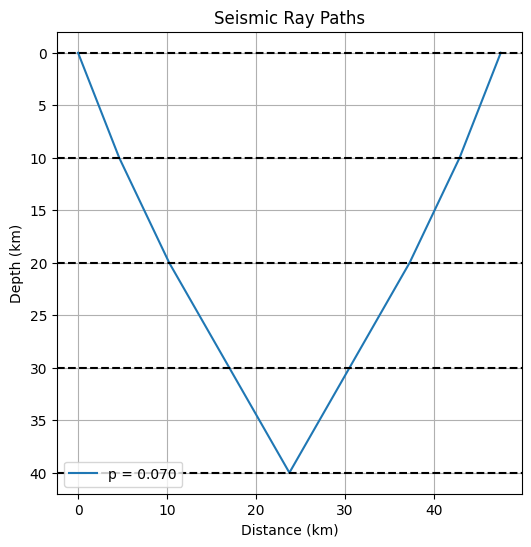

In [29]:
# -------------------------------------------------
# Example Earth model with LVZ
# -------------------------------------------------

h = [10, 10, 10, 10]      # layer thickness (km)
#v = [6, 8, 5, 8]          # velocity model (km/s)
v = [6,7,8,8]
# ray parameters
p_values = np.linspace(0.07, 0.07, 1)

plot_rays(h, v, p_values)